# Car Price Prediction
Predict the selling price of a used car using Machine Learning.

## Step 1: Import Libraries

In [27]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Step 2: Load the Dataset

In [15]:
data = pd.read_csv('Vehicle.csv')
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [16]:
print('Shape:', data.shape)

Shape: (8128, 13)


## Step 3: Clean the Data

In [17]:
data['mileage']   = data['mileage'].str.extract(r'([\d.]+)').astype(float)
data['engine']    = data['engine'].str.extract(r'([\d.]+)').astype(float)
data['max_power'] = data['max_power'].str.extract(r'([\d.]+)').astype(float)

data = data.drop(columns=['name', 'torque'])
data = data.dropna()

print('Cleaned data shape:', data.shape)

Cleaned data shape: (7906, 11)


## Step 4: Encode Categorical Columns

Machine learning models need numbers, so we convert text columns to numbers.
We also save the encoding mapping so the Flask app can use the same encoding.

In [4]:
# These columns have text values that need to be converted to numbers
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']

encoders = {}

for col in cat_cols:
    unique_values = sorted(data[col].unique())   # sort so encoding is consistent
    mapping = {val: idx for idx, val in enumerate(unique_values)}
    encoders[col] = mapping
    data[col] = data[col].map(mapping)
    print(f'{col}: {mapping}')

fuel: {'CNG': 0, 'Diesel': 1, 'LPG': 2, 'Petrol': 3}
seller_type: {'Dealer': 0, 'Individual': 1, 'Trustmark Dealer': 2}
transmission: {'Automatic': 0, 'Manual': 1}
owner: {'First Owner': 0, 'Fourth & Above Owner': 1, 'Second Owner': 2, 'Test Drive Car': 3, 'Third Owner': 4}


## Step 5: Split into Features and Target

In [5]:
X = data.drop(columns=['selling_price'])
y = data['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training samples:', len(X_train))
print('Testing samples :', len(X_test))

Training samples: 6324
Testing samples : 1582


## Step 6: Train the Model

In [23]:
models = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree'     : DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    results.append({'Model': name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R2 Score': round(r2, 4)})
    print(f'{name:22s} -> R2: {r2:.4f} | MAE: {mae:,.0f} | RMSE: {rmse:,.0f}')

results_df = pd.DataFrame(results).sort_values('R2 Score', ascending=False)
print('\nModel Comparison Table:')
results_df

Linear Regression      -> R2: 0.6939 | MAE: 270,328 | RMSE: 461,311
Decision Tree          -> R2: 0.9655 | MAE: 89,391 | RMSE: 154,897
Random Forest          -> R2: 0.9828 | MAE: 65,204 | RMSE: 109,288

Model Comparison Table:


,Model,MAE,RMSE,R2 Score
2,Random Forest,65203.84,109287.70,0.9828
1,Decision Tree,89391.43,154897.40,0.9655
0,Linear Regression,270328.13,461310.86,0.6939


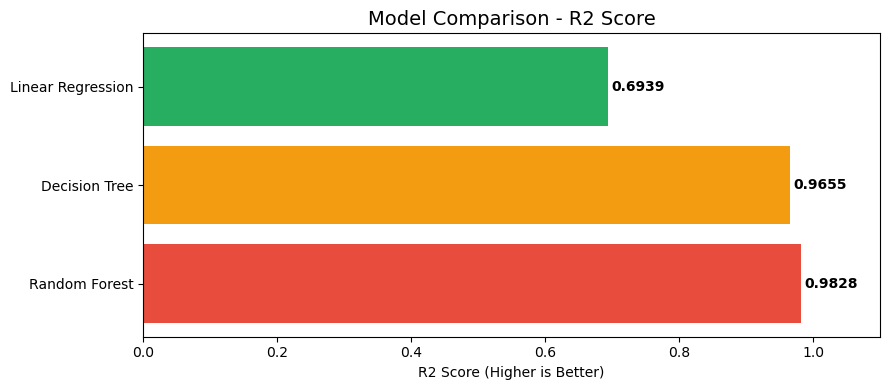

In [28]:
plt.figure(figsize=(9, 4))
colors = ['#e74c3c', '#f39c12', '#27ae60', '#2980b9']
bars = plt.barh(results_df['Model'], results_df['R2 Score'], color=colors)
plt.xlabel('R2 Score (Higher is Better)')
plt.title('Model Comparison - R2 Score', fontsize=14)
for bar, val in zip(bars, results_df['R2 Score']):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontweight='bold')
plt.xlim(0, 1.1)
plt.tight_layout()
plt.show()

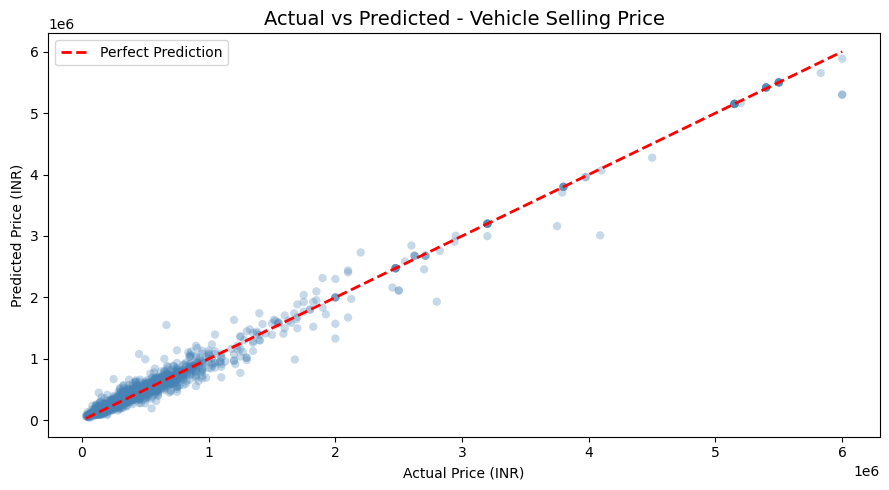

In [30]:
plt.figure(figsize=(9, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='none')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price (INR)')
plt.ylabel('Predicted Price (INR)')
plt.title('Actual vs Predicted - Vehicle Selling Price', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print('Model trained!')

Model trained!


## Step 8: Save the Model and Encoders

We save the trained model and encoders as `.pkl` files so the Flask app (`app.py`) can load and use them.

In [9]:
# Save the trained model
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the encoders (the text-to-number mappings)
with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print('model.pkl saved!')
print('encoders.pkl saved!')

model.pkl saved!
encoders.pkl saved!


## Step 9: Test a Prediction

Let's predict the price of one sample car.

In [10]:
sample = pd.DataFrame([{
    'year'        : 2018,
    'km_driven'   : 45000,
    'fuel'        : encoders['fuel']['Diesel'],
    'seller_type' : encoders['seller_type']['Individual'],
    'transmission': encoders['transmission']['Manual'],
    'owner'       : encoders['owner']['First Owner'],
    'mileage'     : 21.0,
    'engine'      : 1498,
    'max_power'   : 100.0,
    'seats'       : 5
}])

predicted_price = model.predict(sample)[0]
print(f'Predicted Price: ₹{predicted_price:,.0f}')

Predicted Price: ₹797,152
